In [2]:
import pandas as pd

# 1. Read the newly saved CSV file
df = pd.read_csv('data/cleaned_loan_data_revised.csv')

# 2. Extract the column names into a native Python list
clean_columns = df.columns.tolist()

# 3. Print the total count and the list of columns
print(f"Total columns loaded: {len(clean_columns)}\n")
print("--- Cleaned Dataset Columns ---")
for col in clean_columns:
    print(col)

Total columns loaded: 15

--- Cleaned Dataset Columns ---
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
CNT_CHILDREN
CNT_FAM_MEMBERS
FLAG_OWN_CAR
FLAG_OWN_REALTY
NAME_HOUSING_TYPE
TARGET
AGE_YEARS
YEARS_EMPLOYED
FLAG_EMP_ANOMALY
CREDIT_INCOME_RATIO
ADULT_IN_HOUSE
ANNUITY_MONTHLY_INCOME_RATIO


In [3]:
# Moved the two FLAG columns here
categorical_cols = [
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 
    'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_EMP_ANOMALY'
]

# Removed the two FLAG columns and the duplicate HOUSING column
numerical_cols = [
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS','AGE_YEARS', 
    'YEARS_EMPLOYED', 'CREDIT_INCOME_RATIO', 'ADULT_IN_HOUSE',
    "ANNUITY_MONTHLY_INCOME_RATIO"
]

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        # Apply standard scaling to numerical features
        ('num', StandardScaler(), numerical_cols),
        
        # Apply One-Hot Encoding to categorical features
        # handle_unknown='ignore' prevents crashes if a weird category pops up in the future
        # drop='first' helps prevent multicollinearity by dropping one binary column per category
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ])


In [6]:
# Separate features and target
X = df[categorical_cols + numerical_cols]
y = df['TARGET']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='saga',
        l1_ratio=1.0,                
        C=1.0,                       
        max_iter=5000,               # <--- FIX 1: Give the solver more iterations to converge
        class_weight='balanced',     # <--- FIX 2: Force the model to care about defaulters
        random_state=42
    ))
])

In [10]:
print("Training pipeline... (This might take a moment with 5000 iterations)")
log_reg_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = log_reg_pipeline.predict(X_test)
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]

# --- 5. View Results ---
print("\n--- Pipeline Evaluation ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training pipeline... (This might take a moment with 5000 iterations)


C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(



--- Pipeline Evaluation ---
ROC-AUC Score: 0.6384

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.58      0.72     39562
           1       0.12      0.63      0.20      3490

    accuracy                           0.58     43052
   macro avg       0.53      0.61      0.46     43052
weighted avg       0.88      0.58      0.68     43052



In [13]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {imbalance_ratio:.2f}")

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        scale_pos_weight=imbalance_ratio,
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',       # faster, also enables monotonic constraints later if needed
        random_state=42,
        n_jobs=-1
    ))
])

# Widen the grid — your original space is fairly narrow/conservative
param_distributions_xgb = {
    'classifier__n_estimators': randint(200, 800),
    'classifier__learning_rate': uniform(0.005, 0.15),
    'classifier__max_depth': randint(3, 10),
    'classifier__min_child_weight': randint(1, 10),      # controls overfitting on minority patterns
    'classifier__gamma': uniform(0, 5),                  # min loss reduction to split further
    'classifier__subsample': uniform(0.5, 0.5),
    'classifier__colsample_bytree': uniform(0.5, 0.5),
    'classifier__reg_alpha': uniform(0, 5),               # L1
    'classifier__reg_lambda': uniform(0.5, 5),             # L2
}

# CRITICAL: stratify your folds, especially with imbalance
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=39)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions_xgb,
    n_iter=100,
    scoring='roc_auc',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=39,
    verbose=2
)

random_search_xgb.fit(X_train, y_train)

Calculated scale_pos_weight: 11.34
Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': <scipy.stats....002169672FE50>, 'classifier__gamma': <scipy.stats....002169671B680>, 'classifier__learning_rate': <scipy.stats....002169671ACF0>, 'classifier__max_depth': <scipy.stats....002169675B9B0>, ...}"
,n_iter,100
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,39
,error_score,nan


In [14]:
best_params = {k.replace('classifier__', ''): v for k, v in random_search_xgb.best_params_.items()}

final_model = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=imbalance_ratio,
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

final_model.fit(
    X_train_transformed, y_train,
    eval_set=[(X_test_transformed, y_test)],
    verbose=False
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,np.float64(0.9920084534167666)
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'auc'


Test ROC-AUC Score: 0.6480


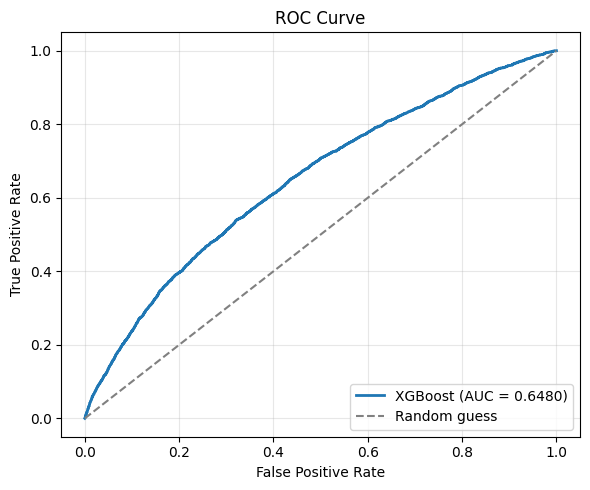

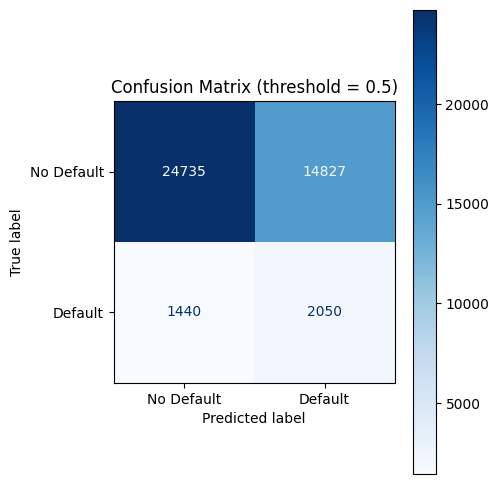


Classification Report:
              precision    recall  f1-score   support

  No Default       0.94      0.63      0.75     39562
     Default       0.12      0.59      0.20      3490

    accuracy                           0.62     43052
   macro avg       0.53      0.61      0.48     43052
weighted avg       0.88      0.62      0.71     43052



In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve, 
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# --- Predictions ---
y_pred = best_xgb_model.predict(X_test)
y_prob = best_xgb_model.predict_proba(X_test)[:, 1]

# --- ROC-AUC Score ---
auc_score = roc_auc_score(y_test, y_prob)
print(f"Test ROC-AUC Score: {auc_score:.4f}")

# --- ROC Curve Plot ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Confusion Matrix (default 0.5 threshold) ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.tight_layout()
plt.show()

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))